In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.diffeomorphisms.fixed_origin import FixedOriginDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.inverse_problem_solver.ambient_flow import AmbientFlowSolver
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.nn.module.polynomial_activation import PolynomialActivation
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform
from src.transforms.polynomial_parity import PolynomialParityTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

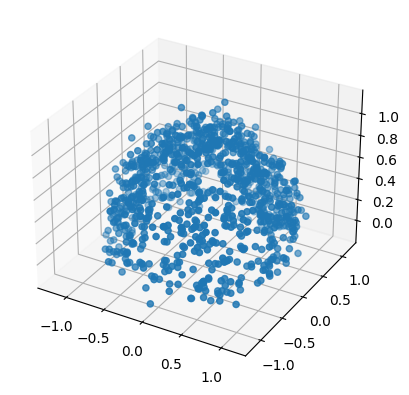

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_train_clean = uniform_sphere_sampling(3, num_samples)
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class IdentityForward(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x
    
    def adjoint_forward(self, x):
        return x

In [4]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(PolynomialParityTransform(dim, order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [5]:
# Define the conditional normalizing flow model
def create_conditional_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(PolynomialParityTransform(dim, context_features=dim, order=order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)


In [6]:
# Initialize the model
forward = IdentityForward()

dim = 3
n_flows = 4
flow = create_flow_model(dim, n_flows, 2)
diffeo = NFlowVectorDiffeomorphism(dim, flow) # TODO try with fixed origin again

n_layers = 4
c_flow = create_conditional_flow_model(dim, n_flows, 2)
c_diffeo = NFlowVectorDiffeomorphism(dim, c_flow)

sparsity_level = 2
model = AmbientFlowSolver(forward, diffeo, c_diffeo, sparsity_level).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [7]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, l1_weight):
    for epoch in range(n_epochs):
        for _, y in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Compute loss
            loss = model.reconstruction_loss(y)

            # Compute regularization on polynomial coefficients
            l1_norm_phi = 0
            for module in model.phi.nflow.modules():
                if isinstance(module, PolynomialParityTransform):
                    # Access the submodule containing activation layers
                    for submodule in module.modules():
                        if isinstance(submodule, PolynomialActivation):
                            if hasattr(submodule, 'coefficients'):
                                # Sum absolute values of polynomial coefficients
                                l1_norm_phi += torch.sum(torch.abs(submodule.coefficients))
            loss += l1_weight * l1_norm_phi

            # Compute regularization on polynomial coefficients
            l1_norm_phi = 0
            for module in model.phy.nflow.modules():
                if isinstance(module, PolynomialParityTransform):
                    # Access the submodule containing activation layers
                    for submodule in module.modules():
                        if isinstance(submodule, PolynomialActivation):
                            if hasattr(submodule, 'coefficients'):
                                # Sum absolute values of polynomial coefficients
                                l1_norm_phi += torch.sum(torch.abs(submodule.coefficients))
            loss += l1_weight * l1_norm_phi

            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")
        # print(model.psi.diagonal)

In [8]:
# Train the model
n_epochs = 100
l1_weight = 0.01
train(model, train_loader, optimizer, n_epochs, l1_weight)

Epoch 1/100, Loss: -4.5383
Epoch 2/100, Loss: -6.5572
Epoch 3/100, Loss: -10.1888
Epoch 4/100, Loss: -16.8087
Epoch 5/100, Loss: -35.3912
Epoch 6/100, Loss: -83.8649
Epoch 7/100, Loss: -486.9418
Epoch 8/100, Loss: -2196.1882
Epoch 9/100, Loss: -4414.0630
Epoch 10/100, Loss: -10691.8467
Epoch 11/100, Loss: -34702.3750
Epoch 12/100, Loss: -54342.3125
Epoch 13/100, Loss: -337518.0000
Epoch 14/100, Loss: -43863.1992
Epoch 15/100, Loss: -458051.5625
Epoch 16/100, Loss: -123331.5156
Epoch 17/100, Loss: -108605.0078
Epoch 18/100, Loss: -115990.9375
Epoch 19/100, Loss: -69218.9297
Epoch 20/100, Loss: -17413.2305
Epoch 21/100, Loss: -11337.6963
Epoch 22/100, Loss: -9397.1787
Epoch 23/100, Loss: -10374.1494
Epoch 24/100, Loss: -9396.7256
Epoch 25/100, Loss: -9494.1875
Epoch 26/100, Loss: -10168.1436
Epoch 27/100, Loss: -10737.6270
Epoch 28/100, Loss: -10242.1250
Epoch 29/100, Loss: -10182.1592
Epoch 30/100, Loss: -11271.6367
Epoch 31/100, Loss: -10086.3164
Epoch 32/100, Loss: -10703.5410
Epoch 3

In [21]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

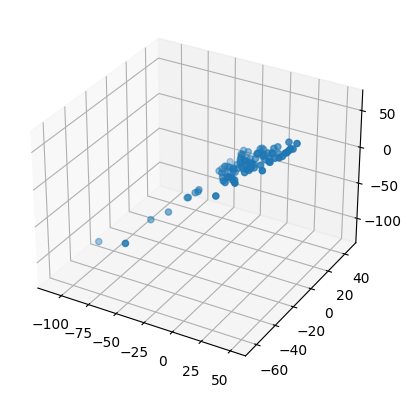

In [24]:
# Visualize generated samples
samples = generate_samples(model.phi.nflow, 100)

ax = plt.axes(projection='3d')
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
plt.show()

### Evaluating Geometry ###

In [9]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi)

In [10]:
# special points
x0 = torch.tensor([0.,0.,1.]).to(device)
x1 = torch.tensor([0.,-1.,0.]).to(device)

In [11]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

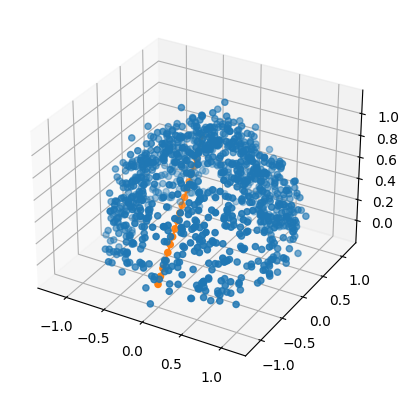

In [12]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [13]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
print(bary)
print(data_train.mean(0))

tensor([0.0401, 0.0219, 0.4908], grad_fn=<SelectBackward0>)
tensor([0.0321, 0.0136, 0.4825])


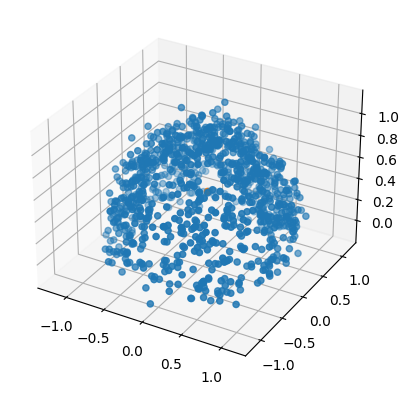

In [14]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [15]:
# construct curvature corrected l2-pga solver
l2_pga_solver = l2TangentSpacePCAVectorSolver(data_train.to(device), manifold, bary)

In [16]:
# compute low rank approximations
l2_pga_solver.solve(2) # compute rank 2 approximation

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


In [17]:
# compute approximations
approximations = l2_pga_solver.exp_x_Xi[2]

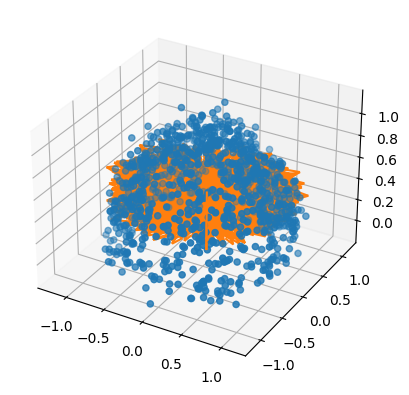

In [18]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 0], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 1], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


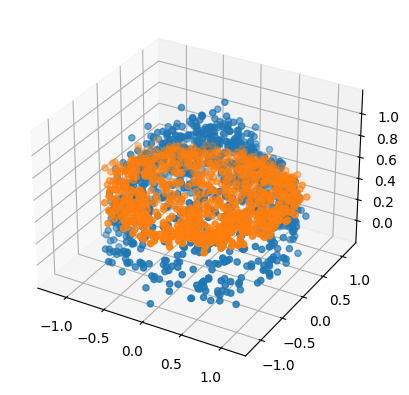

In [19]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(approximations.detach().cpu().numpy()[:,0], approximations.detach().cpu().numpy()[:,1], approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [20]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations)**2,0).sum())

tensor(0.0894, grad_fn=<SumBackward0>)
